# 회귀분석기반의 예측 모델 이해

과거의 데이터 안에서 규칙을 찾아서 미래값을 계산하는 것이 예측 모델(Forecasting Model)이다. 이 에측 모델의 가장 기반되는 방법이 회귀분석(Regression Analysis)이다.

## 예측

예측(Forecast)은 지금까지 관측한 데이터와 그 안의 규칙을 바탕으로 아직 관측하지 않은 미래 값을 '범위와 함께' 추정하는 일을 의미한다.

좋은 예측은 한 점의 숫자와 함께 그 숫자가 얼마나 틀릴 수 있는지를 같이 알려준다. 예측은 미래를 맞히는 확정적인 일이 아니라. 과거의 규칙이 계속된다면 이라는 조건이 붙은 계산 결과이다. 예측은 비슷해보이는 다른 숫자들과 구분이 가능해야된다. 예측과 목표를 섞어서 사용하는 경우가 왕왕있는데, 목표는 이만큼 달성하고 싶다에 대한 의지인것이고, 예측은 지금 흐름이면 이만큼 될 것이다라는 전망이다.

- 예측: 지금 흐름이면 얼마가 될가?, 과거 데이터와 모델
- 목표: 얼마를 달성하고 싶ㅍ은 것인가?, 정책, 방향
- 계획: 무엇을 준비할 것인가?, 예측과 목표를 비교한 후 결정
- 추정: 이미 지난 값은 얼마였는가?, 부분자료로 계산

### 예측 모델 구성

예측 모델은 입력값(Input)을 넣으면 예측값(Output)을 돌려주는 계산 규칙을 의미한다. 에측 모델은 몇 번째 달인가, 몇 월이낙, 명절이 있는가 등의 입력을 받아서 이번달 물동량이 얼마다라는 예측값을 출력해준더.

- 예측모댈
  - 목표값(Target, Y): 맞히고자 하는 값
  - 특성(Feature, X): 목표값을 설명할 수 있는 입력
  - 모델(Model): X와 Y를 잇는 계산규칙(회귀식)
    - 파라미터(Parameter): 학습으로 정해지는 값(회귀계수) - 데이터
    - 하이퍼파라미터(Hyper Parameter): 사람이 정하는 값 - 우리가 지정
  - 학습(fit): 고거 데이터로 파라미터를 정하는 과정
  - 예측(Predict): 새 x를 넣어 y를 계산하는 과정
  - 평가(Evaluate): 모델이 보지 않은 실제 값과의 비교

## 회귀분석

회귀분석(Regression Analysis)은 한 변수(목표값)가 다른 변수(특성)에 따라 어떻게 변하는지를 식으로 나타내는 분석방법이다.

선박의 총톤수가 클수록 하역시간이 길어지는 경향이 있다고 한다면, '총 톤수가 1만톤 늘어날 때 하역시간이 평균 몇시간 늘어나겠는가'를 숫자로 알려주는게 회귀분석인 것이다.

설명하려는 값이 종속변수(Dependent Variable), 설명에 쓴이는 값이 독립변수(Independent Variable) 이다.

### 회귀분석의 종류
- 단순 선형회귀: 연도 -> 연간 환적 물동량
- 다중 선형회귀: 추세, 월, 명절 -> 월별 환적 물동량
- 다항회귀: 곡선 추세
- 로지스틱 회귀: 확률 문제

### 최소제곱법

회귀선(Regression Line)은 흩어진 점들 사이를 가장 잘 지나가는 직선으로 정의할 수 있다.
'가장 잘 지나가는'의  기준이 필요하다. 선형회귀(Linear Regression)는 각 점에서 직선까지의 세로거리(잔차(Residual))를 제곱해서 모두 더한 갑싱 가장 작아지는 직선을 고른다.

이 방법을 최소제곱법(OLS, Ordinary Least Squares)이라고 일 컫는다. 잔차가 음수가 나올수 있기 때문에, 위쪽 잔차와 아래쪽 잔차의 상쇄를 막고, 크게 벗어난 점에 대해서 더 큰 벌점을 주기 위해서이다.

# tranship -> 물동량
# 독립변수: 알고자하는 값을 설명하는 것(원인과 입력값)
# x, y는 독립변수와 종속변수
# fit 학습
# x는 years y는 tranship

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from streamlit import columns

years = np.array([2018, 2019, 2020, 2021, 2022, 2023])
tranship = np.array([1150, 1170, 1210, 1235, 1185, 1250])

x_mean, y_mean = years.mean(), tranship.mean()
b1 = ((years - x_mean) * (tranship - y_mean)).sum() / ((years - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean

print(round(b1, 2)) # 기울기
print(round( b0 + b1 * 2024 , 1))

16.29
1257.0


In [5]:
model = LinearRegression()
model.fit(years.reshape(-1, 1), tranship) # y - wx + b

print(round(model.coef_[0], 2))
print(round(model.intercept_, 1))


16.29
-31705.3


In [6]:
fitted = model.predict(years.reshape(-1, 1))
residuals = tranship - fitted


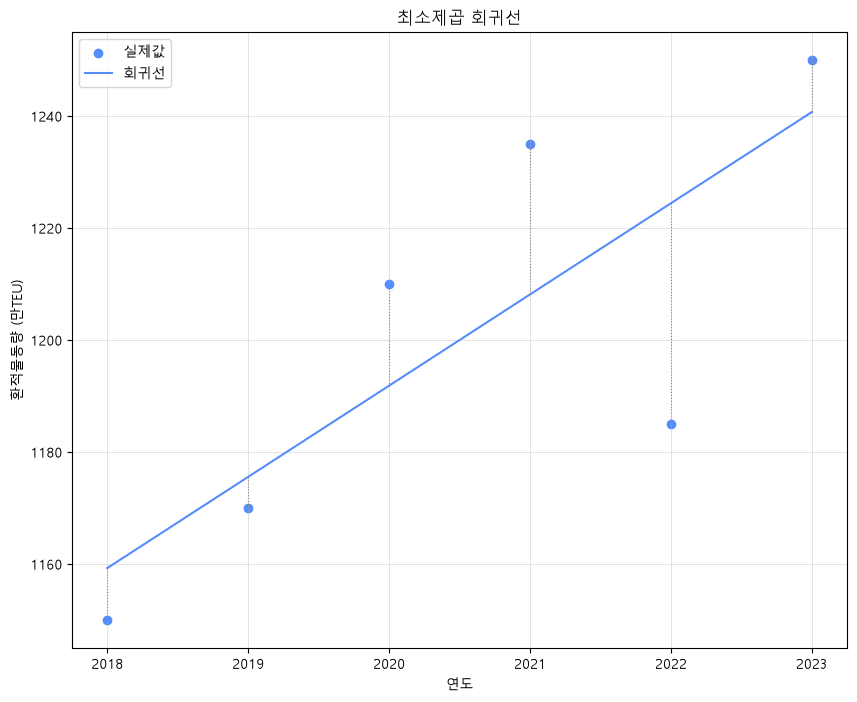

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(10, 8))


ax.scatter(years, tranship, label='실제값')
ax.plot(years, fitted, label='회귀선')
ax.vlines(years, fitted, tranship, color='gray', linestyles=":", linewidth=0.8)

ax.set_xlabel('연도')
ax.set_ylabel('환적물동량 (만TEU)')

ax.set_title('최소제곱 회귀선')

ax.legend()
ax.grid(True)

plt.show()

In [8]:
#model.predict([[2024]])[0]
model.predict([[2025]])[0]

np.float64(1273.2857142857174)

## 결정계수 ($R^2$)

회귀선을 그렸으면 '이 지석이 데이터를 얼마나 잘 설명하는가?를 구체적으로 알고싶어진다. 구체적으로 알고싶어진다는 곧 숫자로 설명하고 싶어진다를 의미한다. 결정계수(Coefficient of Determination)는 목표값이 평균 주변에 흩어진 전체 변동 가운데 회귀선이 설명한 몫을 0~1사이로 나타낸다.
결정계수가 0.8이면, 환적 물동량이 해마다 달라진 정도의 80%를 연도(추세)로 설명할 수 있다.

- 결정계수는 학습에 쓴 데이터를 얼마나 잘 설명하는지를 표현할 뿐이지, 얼마나 미래를 잘 맞히는지는 대표할 수 없다.
- 특성을 게속 추가하면 결정계수는 올라가지만, 미래 예측결과는 나빠질 수 있다(과적함)
- 추세가 강한 시계열은 연도 하나만 넣어도 결정게수가 높게 나온다, 시계열 예측 모델은 결정계수를 보는 것이 아니라 평균 구간 오차(MAE)를 보아야한다.

## 회귀 예측 모델을 만드는 정차

1. KPI정하기: 무엇을, 어떤 단위로, 몇달 앞까지 예측할까?
2. 특성 설계: 추세, 월, 달력 등 미래에도 미리 알 수 있는 값을 설계
3. 시간 순서 분할: 앞부분 학습을 위해 시간 단위 분할
4. 베이스라인: 최근 몇개월에 대한 평균
5. 학습: 회귀계수 추정
6. 평가
7. 전차점검
8. 하이퍼피라미터
9. 재학습 및 예측

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

plt.rcParams['font.family'] = 'Malgun Gothic'



In [12]:
def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

In [15]:
df = load_dataset('물동량_예측')

df

,연도,월,연월,수출입구분,수출입구분설명,물동량
0,2003,2,2003-02,OT,수출환적,161074.50
1,2003,11,2003-11,IT,수입환적,170733.50
2,2006,1,2006-01,OT,수출환적,203348.25
3,2018,1,2018-01,OO,수출,413797.75
4,2013,6,2013-06,OO,수출,389650.25
...,...,...,...,...,...,...
1371,1996,1,1996-01,OO,수출,158518.00
1372,2001,6,2001-06,OO,수출,215325.25
1373,2001,9,2001-09,OT,수출환적,127883.00
1374,2004,1,2004-01,IT,수입환적,181137.50


In [16]:
ts = df.pivot(index='연월', columns='수출입구분설명', values='물동량')
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('MS')

ts

수출입구분설명,수입,수입환적,수출,수출환적
연월,,,,
1992-01-01,92005.00,NaN,104567.00,NaN
1992-02-01,91669.00,NaN,103903.00,NaN
1992-03-01,105276.00,NaN,137082.00,NaN
1992-04-01,99261.00,NaN,130353.00,NaN
1992-05-01,95773.00,NaN,126586.00,NaN
...,...,...,...,...
2024-10-01,431582.50,574791.75,469171.75,573844.75
2024-11-01,421638.75,571301.25,444568.50,560592.25
2024-12-01,461852.75,593917.50,442416.25,569233.75


In [18]:
tranship = (ts['수출환적'] + ts['수입환적']).loc['2001-01':] # 환적데이터 있는 기간동안 환적 구하기
total = ts.sum(axis=1, min_count=4).loc['2001-01':] # 지표 4개 다있는 값 합산
share = tranship / total * 100 # 환적비중

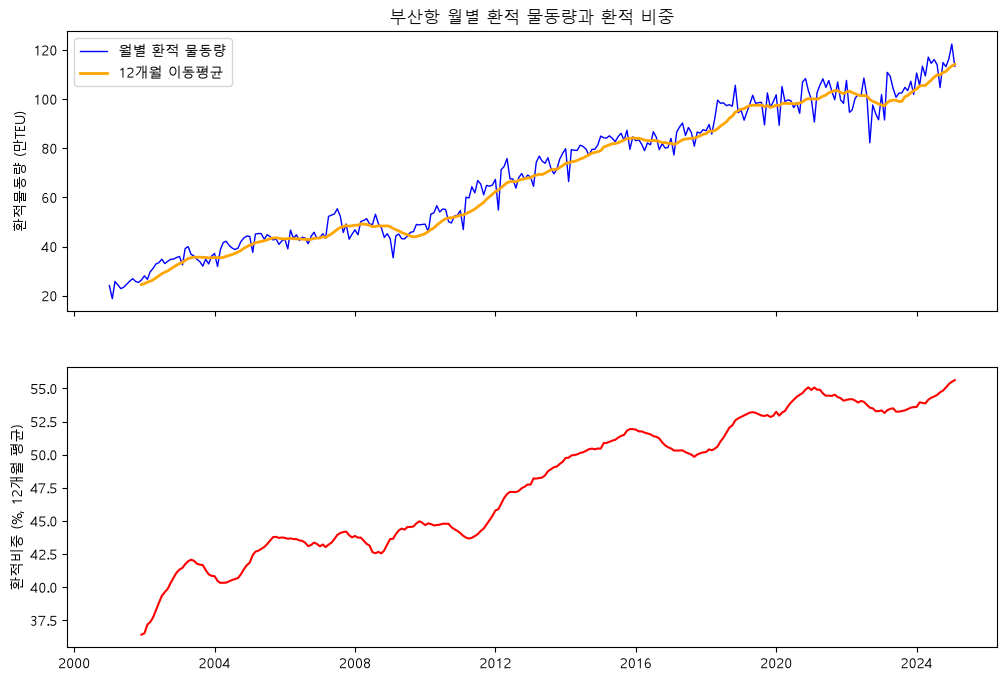

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(tranship / 10_000, color='blue', linewidth=1, label='월별 환적 물동량')
axes[0].plot(tranship.rolling(12).mean() / 10_000, color='orange', linewidth=2, label='12개월 이동평균')

axes[0].set_ylabel('환적물동량 (만TEU)')
axes[0].set_title('부산항 월별 환적 물동량과 환적 비중')
axes[0].legend()

axes[1].plot(share.rolling(12).mean(), color='red')
axes[1].set_ylabel('환적비중 (%, 12개월 평균)')

plt.show()


## 시간순서 분할 및 베이스라인

24개월(23~25) -> 평가용 데이터로 분리

01~23 학습용

시간 순서대로 정렬해서 학습에 사용

---

모델을 평가하기 위해서는 기준이 필요했다. 베이스라인(Baseline)은 모델 없이도 만들 수 있는 가장 간단한 예측선.



In [21]:
TEST_LEN = 24 # 마지막 24개월

y_train, y_test = tranship.iloc[:-TEST_LEN], tranship.iloc[-TEST_LEN:]

print(y_train.index[0].date(), y_train.index[-1].date(), len(y_train))
print(y_test.index[0].date(), y_test.index[-1].date(), len(y_test))

2001-01-01 2023-02-01 266
2023-03-01 2025-02-01 24


### 특성
특성은 모델에 넣는 입력 열이다. 모델이 예측할 값을 설명하는 변수로 정리한 바 있다.
우리가 다루는 원본 데이터에는 연월과 환적량 두 개의 열 밖에 없다. 그런데 회귀모델은 특정 월을 보고 물동량이 적겠구나, 많겠구나를 판단하지 못한다.
따라서 어떤 열을 주느냐가 곧 모델이 알 수 있는 전부이다. 날짜안에 들어있는 정보를 꺼내 숫자 열로 펼쳐줘야 해당 정보를 사용할 수 있게 된다.

In [26]:
SEOLLAL = ["2001-01-24", "2002-02-12", "2003-02-01", "2004-01-22", "2005-02-09", "2006-01-29", "2007-02-18",
           "2008-02-07", "2009-01-26", "2010-02-14", "2011-02-03", "2012-01-23", "2013-02-10", "2014-01-31",
           "2015-02-19", "2016-02-08", "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
           "2022-02-01", "2023-01-22", "2024-02-10", "2025-01-29", "2026-02-17"]          # 설날 당일 (양력)
CHUSEOK = ["2001-10-01", "2002-09-21", "2003-09-11", "2004-09-28", "2005-09-18", "2006-10-06", "2007-09-25",
           "2008-09-14", "2009-10-03", "2010-09-22", "2011-09-12", "2012-09-30", "2013-09-19", "2014-09-08",
           "2015-09-27", "2016-09-15", "2017-10-04", "2018-09-24", "2019-09-13", "2020-10-01", "2021-09-21",
           "2022-09-10", "2023-09-29", "2024-09-17", "2025-10-06", "2026-09-25"]          # 추석 당일 (양력)
seollal_months = pd.to_datetime(SEOLLAL).to_period("M")
chuseok_months = pd.to_datetime(CHUSEOK).to_period("M")

def make_features(index: pd.DatetimeIndex, origin: str = "2001-01-01") -> pd.DataFrame:
    """월별 인덱스로 추세·월 더미·일수·명절 더미를 만든다 (모두 미래에도 미리 알 수 있는 값)."""
    start = pd.Timestamp(origin)
    X = pd.DataFrame(index=index)
    X["추세"] = (index.year - start.year) * 12 + (index.month - start.month)   # origin 달 = 0
    for m in range(2, 13):                                                    # 1월은 기준 범주라 뺌
        X[f"{m}월"] = (index.month == m).astype(int)
    X["일수"] = index.days_in_month
    X["설날월"] = index.to_period("M").isin(seollal_months).astype(int)
    X["추석월"] = index.to_period("M").isin(chuseok_months).astype(int)
    return X
X_all = make_features(tranship.index)

print(X_all.shape)
print(X_all.columns.tolist())

month_cols = [f'{i}월' for i in range(2, 13)]

feature_cols = (
    ['추세']
    + month_cols
    + ['일수', '설날월', '추석월']
)

X = X_all[feature_cols]

print(X.head())
print(X.shape)

(290, 15)
['추세', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월', '일수', '설날월', '추석월']
            추세  2월  3월  4월  5월  6월  7월  8월  9월  10월  11월  12월  일수  설날월  추석월
연월                                                                         
2001-01-01   0   0   0   0   0   0   0   0   0    0    0    0  31    1    0
2001-02-01   1   1   0   0   0   0   0   0   0    0    0    0  28    0    0
2001-03-01   2   0   1   0   0   0   0   0   0    0    0    0  31    0    0
2001-04-01   3   0   0   1   0   0   0   0   0    0    0    0  30    0    0
2001-05-01   4   0   0   0   1   0   0   0   0    0    0    0  31    0    0
(290, 15)


In [28]:
# 모델을 3개


feature_sets = {
    '모델1': ['추세'],

    '모델2': ['추세'] + [f'{i}월' for i in range(2, 13)],

    '모델3': list(X_all.columns)
}

predictions = {}
fitted_models = {}

for name, cols in feature_sets.items():
    reg = LinearRegression()

    reg.fit(X_train[cols], y_train)

    fitted_models[name] = reg

    predictions[name] = pd.Series(
        reg.predict(X_test[cols]),
        index=y_test.index
    )


#coef 회귀계수

In [30]:
best_model_name = '모델2'

best_cols = feature_sets[best_model_name]
best_model = fitted_models[best_model_name]

coef = pd.Series(
    best_model.coef_,
    index=best_cols
)

print(f'월별 추세 계수: {round(coef["추세"])}')
print(f'연간 추세 계수: {round(coef["추세"] * 12)}')

월별 추세 계수: 3166
연간 추세 계수: 37995


C:\work\JupyterProject3\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


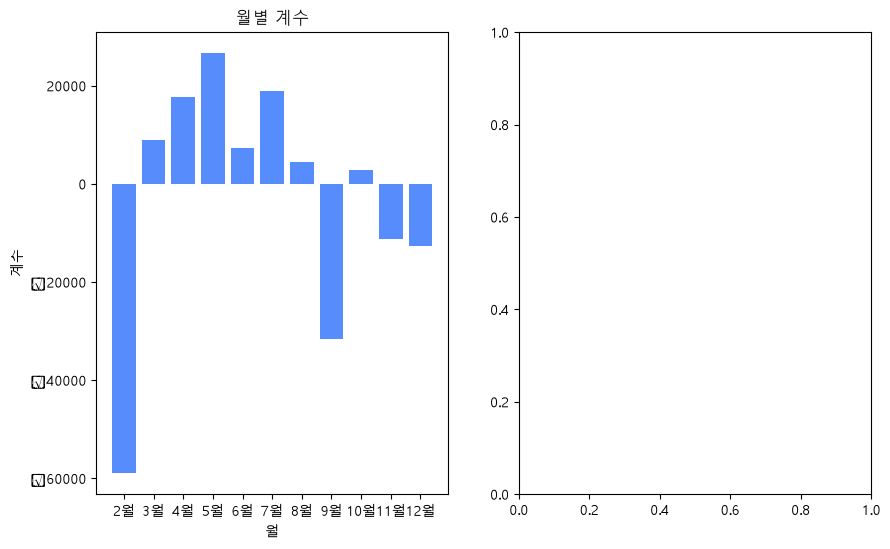

In [33]:
month_coef = coef[[f'{i}월' for i in range(2, 13)]]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

axes[0].bar(
    month_coef.index,
    month_coef.values
)

axes[0].set_title('월별 계수')
axes[0].set_xlabel('월')
axes[0].set_ylabel('계수')

plt.show()

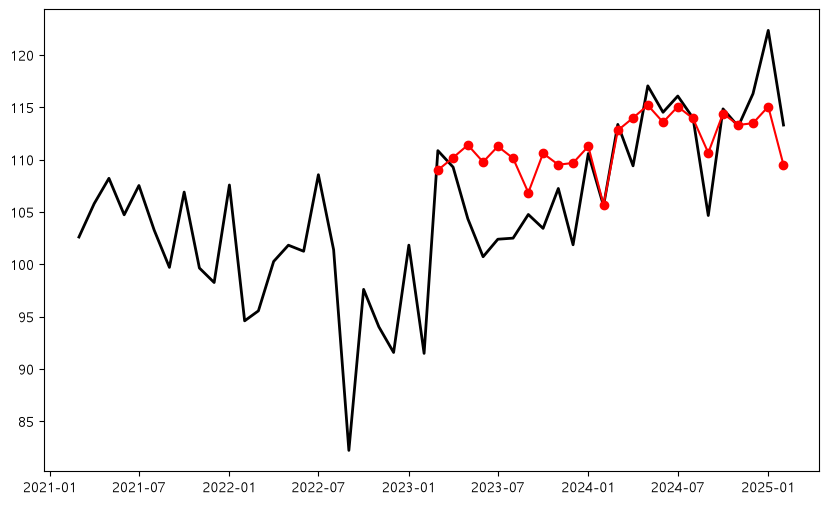

In [32]:
best_pred = predictions[best_model_name]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tranship.loc['2021-03':] / 10_000, color='black', linewidth=2, label='실제값')
ax.plot(best_pred / 10_000, color='red', marker='o',label='예측값')

plt.show()